## Setup

### Configure API keys

To fine-tune YOLO11, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In `Add-ons` > `Secrets`, store the Roboflow API Key under the name `ROBOFLOW_API_KEY`.

In [1]:
!nvidia-smi

Wed Oct 15 10:24:02 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P0             28W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/kaggle/working


## Install YOLO11

In [3]:
%pip install "ultralytics<=8.3.40" supervision roboflow --quiet
%pip install "numpy<2" --quiet
%pip install "ray[tune]<2.10" --quiet

# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6520.1/8062.4 GB disk)


In [4]:
%pip install "ray[tune]<2.10" --quiet

Note: you may need to restart the kernel to use updated packages.


## Fine-tune YOLO11 on custom dataset
**NOTE:** When training YOLOv11, make sure your data is located in `datasets`.

In [5]:
!pip install roboflow
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from kaggle_secrets import UserSecretsClient
from roboflow import Roboflow

user_secrets = UserSecretsClient()
ROBOFLOW_API_KEY = user_secrets.get_secret("ROBOFLOW_API_KEY")
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("skripsi-bjayz")
project = workspace.project("data-sampah-gza9k")
version = project.version(1)
dataset = version.download("yolov11")

/kaggle/working/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Data-Sampah-1 in yolov11:: 100%|██████████| 34846/34846 [00:04<00:00, 8237.51it/s]


In [6]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11n.pt data={dataset.location}/data.yaml epochs=100 imgsz=640 plots=True

/kaggle/working
100%|███████████████████████████████████████| 5.35M/5.35M [00:00<00:00, 193MB/s]
New https://pypi.org/project/ultralytics/8.3.214 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/kaggle/working/datasets/Data-Sampah-1/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buf

In [7]:
import os

# Check if training directory exists
train_dir = f'{HOME}/runs/detect/train/'
if os.path.exists(train_dir):
    !ls {HOME}/runs/detect/train/
else:
    print(f"Training directory not found at {train_dir}")
    print("Please run the training cell first!")

args.yaml					  train_batch1.jpg
confusion_matrix_normalized.png			  train_batch2.jpg
confusion_matrix.png				  train_batch68580.jpg
events.out.tfevents.1760524033.57880da5877e.89.0  train_batch68581.jpg
F1_curve.png					  train_batch68582.jpg
labels_correlogram.jpg				  val_batch0_labels.jpg
labels.jpg					  val_batch0_pred.jpg
P_curve.png					  val_batch1_labels.jpg
PR_curve.png					  val_batch1_pred.jpg
R_curve.png					  val_batch2_labels.jpg
results.csv					  val_batch2_pred.jpg
results.png					  weights
train_batch0.jpg


In [8]:
import os
from IPython.display import Image as IPyImage

confusion_matrix_path = f'{HOME}/runs/detect/train/confusion_matrix.png'
if os.path.exists(confusion_matrix_path):
    IPyImage(filename=confusion_matrix_path, width=600)
else:
    print(f"File not found: {confusion_matrix_path}")
    print("Please ensure the training has completed successfully.")

In [9]:
import os
from IPython.display import Image as IPyImage

results_path = f'{HOME}/runs/detect/train/results.png'
if os.path.exists(results_path):
    IPyImage(filename=results_path, width=600)
else:
    print(f"File not found: {results_path}")
    print("Please ensure the training has completed successfully.")

In [10]:
import os
from IPython.display import Image as IPyImage

val_batch_path = f'{HOME}/runs/detect/train/val_batch0_pred.jpg'
if os.path.exists(val_batch_path):
    IPyImage(filename=val_batch_path, width=600)
else:
    print(f"File not found: {val_batch_path}")
    print("Please ensure the training has completed successfully.")

## Validate fine-tuned model

In [11]:
import os

# Check if model weights exist before validation
weights_path = f'{HOME}/runs/detect/train/weights/best.pt'
if os.path.exists(weights_path):
    !yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml
else:
    print(f"Model weights not found at {weights_path}")
    print("Please run the training cell first!")

Ultralytics 8.3.40 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11n summary (fused): 238 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs
val: Scanning /kaggle/working/datasets/Data-Sampah-1/valid/labels.cache... 3484 
                 Class     Images  Instances      Box(P          R      mAP50  m
                   all       3484       4827      0.909      0.852      0.924      0.755
             Anorganik       1199       1543      0.904      0.891      0.945      0.838
               Lainnya       1138       1930      0.884       0.81        0.9      0.726
               Organik       1202       1354      0.938      0.855      0.927      0.701
Speed: 0.2ms preprocess, 2.3ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to runs/detect/val
💡 Learn more at https://docs.ultralytics.com/modes/val


## Inference with custom model

In [12]:
import os

# Check if model weights exist before inference
weights_path = f'{HOME}/runs/detect/train/weights/best.pt'
if os.path.exists(weights_path):
    !yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True
else:
    print(f"Model weights not found at {weights_path}")
    print("Please run the training cell first!")

Ultralytics 8.3.40 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLO11n summary (fused): 238 layers, 2,582,737 parameters, 0 gradients, 6.3 GFLOPs

image 1/1741 /kaggle/working/datasets/Data-Sampah-1/test/images/Anorganik1000_jpg.rf.5f2a76a2066ddab13b88ef1d866a6a9b.jpg: 640x640 1 Anorganik, 8.5ms
image 2/1741 /kaggle/working/datasets/Data-Sampah-1/test/images/Anorganik1037_jpg.rf.dc5ade9534fd278fe424fc1e4af665ab.jpg: 640x640 1 Anorganik, 12.4ms
image 3/1741 /kaggle/working/datasets/Data-Sampah-1/test/images/Anorganik1040_jpg.rf.cd7757f1f6fc9d8c48fe0a852864d1ba.jpg: 640x640 1 Anorganik, 10.1ms
image 4/1741 /kaggle/working/datasets/Data-Sampah-1/test/images/Anorganik1043_jpg.rf.8abf39d98e0560545c9ec7af721ce5fd.jpg: 640x640 1 Anorganik, 9.2ms
image 5/1741 /kaggle/working/datasets/Data-Sampah-1/test/images/Anorganik1066_jpg.rf.17f9e5beb13cfcd5a689862f5ac9e251.jpg: 640x640 1 Anorganik, 9.0ms
image 6/1741 /kaggle/working/datasets/Data-Sampah-1/test/images/Anorga

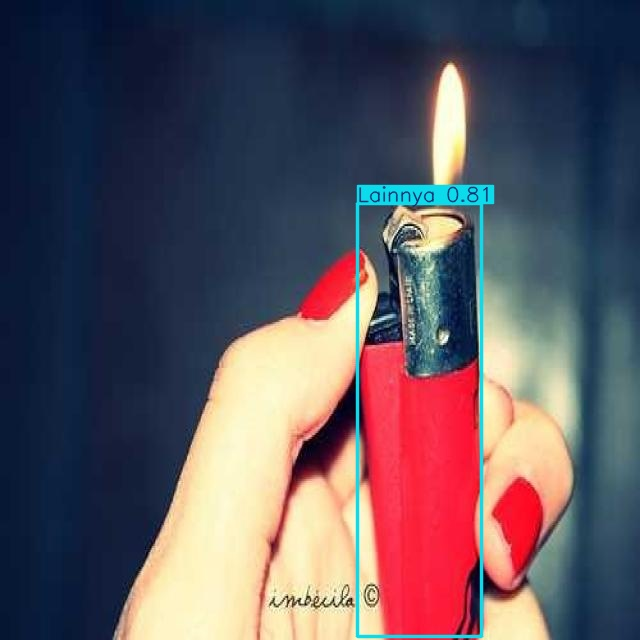

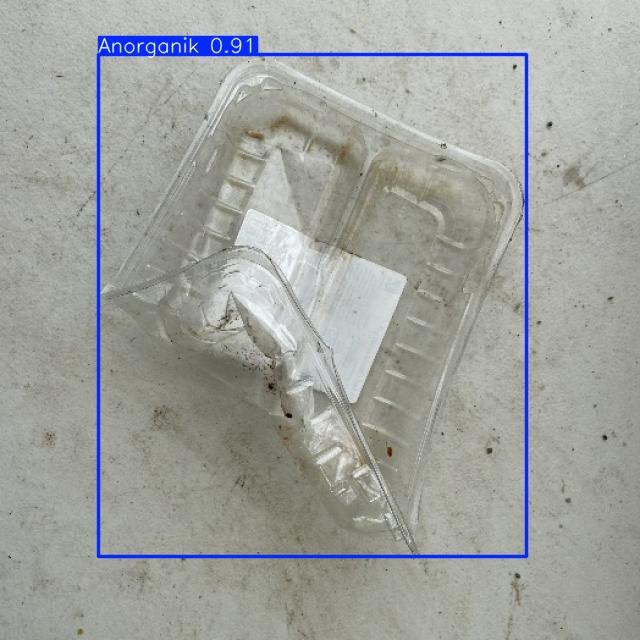

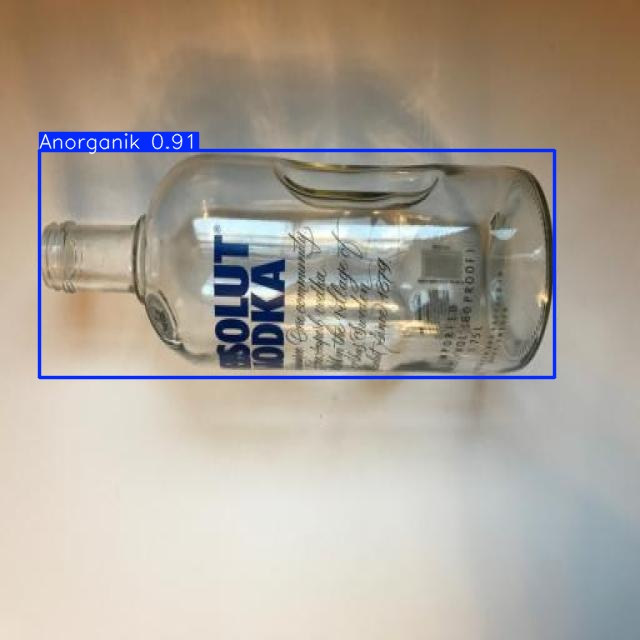

In [13]:
import glob
import os
from IPython.display import Image as IPyImage, display

# Check if prediction results exist
predict_folders = glob.glob(f'{HOME}/runs/detect/predict*/')
if predict_folders:
    latest_folder = max(predict_folders, key=os.path.getmtime)
    image_files = glob.glob(f'{latest_folder}/*.jpg')
    
    if image_files:
        for img in image_files[:3]:
            display(IPyImage(filename=img, width=600))
            print("\n")
    else:
        print(f"No prediction images found in {latest_folder}")
else:
    print("No prediction results found. Please run the inference cell first!")